<a href="https://colab.research.google.com/github/Miftahul-20/Summer_25-26_PYTHON_Final/blob/main/Student_performance_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score, precision_score, recall_score

In [ ]:
url = 'https://raw.githubusercontent.com/Miftahul-20/Summer_25-26_PYTHON_Final/main/Student_performance_analysis.csv'
df_raw = pd.read_csv(url)

df = df_raw.copy()

In [ ]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,course
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,3,4,1,1,3,6,5,6,6,mathematics
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,3,1,1,3,4,5,5,6,mathematics
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,3,2,2,3,3,10,7,8,10,mathematics
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,2,1,1,5,2,15,14,15,mathematics
4,GP,F,16,U,GT3,T,3,3,other,other,...,3,2,1,2,5,4,6,10,10,mathematics


In [ ]:
df = df.drop(columns=['nursery', 'address', 'famsize', 'Pstatus', 'reason', 'Dalc', 'Walc'])

print('Columns after dropping:', df.shape)
print(list(df.columns))

Columns after dropping: (1044, 27)
['school', 'sex', 'age', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'health', 'absences', 'G1', 'G2', 'G3', 'course']


In [ ]:
print(df.shape)
print(list(df.columns))
print(df.dtypes)

(1044, 27)
['school', 'sex', 'age', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'health', 'absences', 'G1', 'G2', 'G3', 'course']
school        object
sex           object
age            int64
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
health         int64
absences       int64
G1             int64
G2             int64
G3             int64
course        object
dtype: object


In [ ]:
missing_count = df.isna().sum()
missing_percentage = df.isna().mean() * 100
missing_report = pd.DataFrame({
    'Missing Count': missing_count
})
print(missing_count)

school        0
sex           0
age           0
Medu          0
Fedu          0
Mjob          0
Fjob          0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
health        0
absences      0
G1            0
G2            0
G3            0
course        0
dtype: int64


In [ ]:
print('Duplicate rows:', df.duplicated().sum())

Duplicate rows: 0


In [ ]:
# G3 >= 10 is Pass (1), below 10 is Fail (0)
df['pass(1) vs fail(0)'] = (df['G3'] >= 10).astype(int)

print(df['pass(1) vs fail(0)'].value_counts())
print(df['pass(1) vs fail(0)'].value_counts(normalize=True))

pass(1) vs fail(0)
1    814
0    230
Name: count, dtype: int64
pass(1) vs fail(0)
1    0.779693
0    0.220307
Name: proportion, dtype: float64


In [ ]:
df = df.drop(columns=['G1', 'G2', 'G3'])

print('Shape after dropping grade columns:', df.shape)
print(list(df.columns))

Shape after dropping grade columns: (1044, 25)
['school', 'sex', 'age', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'health', 'absences', 'course', 'pass(1) vs fail(0)']


In [ ]:
# Binary yes/no columns
binary_cols = ['schoolsup', 'famsup', 'paid', 'activities', 'higher', 'internet', 'romantic']
for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})

# Binary two-value columns
df['sex'] = df['sex'].map({'F': 0, 'M': 1})

# Multi-class categorical columns
multi_cols = ['school', 'Mjob', 'Fjob', 'guardian', 'course']
df = pd.get_dummies(df, columns=multi_cols)

print('Shape after encoding:', df.shape)
print(list(df.columns))

Shape after encoding: (1044, 37)
['sex', 'age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'health', 'absences', 'pass(1) vs fail(0)', 'school_GP', 'school_MS', 'Mjob_at_home', 'Mjob_health', 'Mjob_other', 'Mjob_services', 'Mjob_teacher', 'Fjob_at_home', 'Fjob_health', 'Fjob_other', 'Fjob_services', 'Fjob_teacher', 'guardian_father', 'guardian_mother', 'guardian_other', 'course_mathematics', 'course_portuguese']


In [ ]:
target_column = 'pass(1) vs fail(0)'

feature_columns = [col for col in df.columns if col != target_column]

print('Number of features:', len(feature_columns))
print('Target column:', target_column)

Number of features: 36
Target column: pass(1) vs fail(0)


In [ ]:
X = df[feature_columns].to_numpy(dtype=np.float32)
y = df[target_column].to_numpy()

print('X shape:', X.shape)
print('y shape:', y.shape)

X shape: (1044, 36)
y shape: (1044,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('Training set shape:', X_train.shape, y_train.shape)
print('Test set shape:', X_test.shape, y_test.shape)

print('\nTraining classes:')
print(pd.Series(y_train).value_counts())
print('\nTest classes:')
print(pd.Series(y_test).value_counts())

Training set shape: (835, 36) (835,)
Test set shape: (209, 36) (209,)

Training classes:
1    651
0    184
Name: count, dtype: int64

Test classes:
1    163
0     46
Name: count, dtype: int64


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Training features mean after scaling:')
print(X_train_scaled.mean(axis=0).round(4))
print('Training features std after scaling:')
print(X_train_scaled.std(axis=0).round(4))

Training features mean after scaling:
[ 0.  0. -0.  0.  0. -0.  0. -0.  0. -0.  0.  0. -0. -0.  0.  0. -0.  0.
  0. -0.  0. -0. -0. -0.  0.  0.  0. -0. -0.  0. -0. -0.  0. -0.  0. -0.]
Training features std after scaling:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

results_knn = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred_knn
})

print('=== KNN ===')
print(results_knn.head())
print('\nAccuracy:', accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

=== KNN ===
   Actual  Predicted
0       1          1
1       1          1
2       1          1
3       0          1
4       1          0

Accuracy: 0.7703349282296651
              precision    recall  f1-score   support

           0       0.42      0.11      0.17        46
           1       0.79      0.96      0.87       163

    accuracy                           0.77       209
   macro avg       0.60      0.53      0.52       209
weighted avg       0.71      0.77      0.71       209



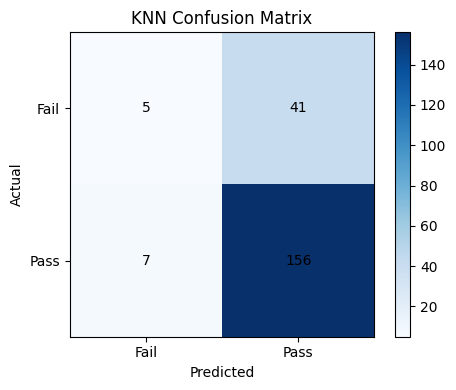

In [ ]:
cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(5, 4))
plt.imshow(cm_knn, cmap='Blues')
plt.title('KNN Confusion Matrix')
plt.colorbar()
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks([0, 1], ['Fail', 'Pass'])
plt.yticks([0, 1], ['Fail', 'Pass'])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm_knn[i, j], ha='center', va='center', color='black')
plt.tight_layout()
plt.show()

In [ ]:
svm = SVC(kernel='rbf', C=1.0, class_weight='balanced', random_state=599)
svm.fit(X_train_scaled, y_train)
y_pred_svm = svm.predict(X_test_scaled)

results_svm = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred_svm
})

print('=== SVM ===')
print(results_svm.head())
print('\nAccuracy:', accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

=== SVM ===
   Actual  Predicted
0       1          0
1       1          1
2       1          1
3       0          1
4       1          0

Accuracy: 0.722488038277512
              precision    recall  f1-score   support

           0       0.40      0.52      0.45        46
           1       0.85      0.78      0.81       163

    accuracy                           0.72       209
   macro avg       0.63      0.65      0.63       209
weighted avg       0.75      0.72      0.73       209



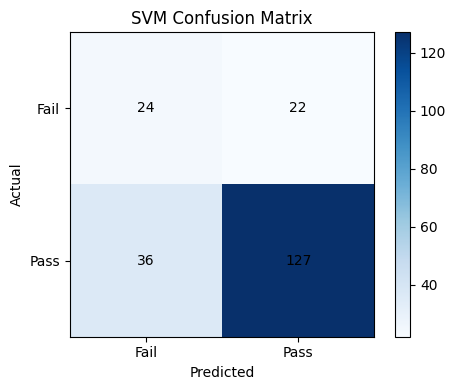

In [ ]:
cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(5, 4))
plt.imshow(cm_svm, cmap='Blues')
plt.title('SVM Confusion Matrix')
plt.colorbar()
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks([0, 1], ['Fail', 'Pass'])
plt.yticks([0, 1], ['Fail', 'Pass'])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm_svm[i, j], ha='center', va='center', color='black')
plt.tight_layout()
plt.show()

In [ ]:
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=599)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)

results_rf = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred_rf
})

print('=== Random Forest ===')
print(results_rf.head())
print('\nAccuracy:', accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

=== Random Forest ===
   Actual  Predicted
0       1          1
1       1          1
2       1          1
3       0          1
4       1          1

Accuracy: 0.7990430622009569
              precision    recall  f1-score   support

           0       0.61      0.24      0.34        46
           1       0.82      0.96      0.88       163

    accuracy                           0.80       209
   macro avg       0.71      0.60      0.61       209
weighted avg       0.77      0.80      0.76       209



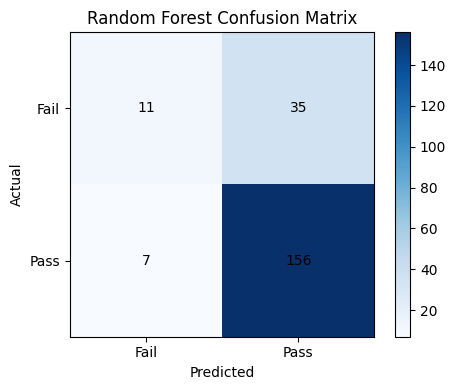

In [ ]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5, 4))
plt.imshow(cm_rf, cmap='Blues')
plt.title('Random Forest Confusion Matrix')
plt.colorbar()
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks([0, 1], ['Fail', 'Pass'])
plt.yticks([0, 1], ['Fail', 'Pass'])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm_rf[i, j], ha='center', va='center', color='black')
plt.tight_layout()
plt.show()

In [ ]:
comparison = pd.DataFrame({
    'Model': ['KNN', 'SVM', 'Random Forest'],
    'Accuracy': [
        round(accuracy_score(y_test, y_pred_knn), 4),
        round(accuracy_score(y_test, y_pred_svm), 4),
        round(accuracy_score(y_test, y_pred_rf), 4)
    ],
    'Precision': [
        round(precision_score(y_test, y_pred_knn, average='weighted'), 4),
        round(precision_score(y_test, y_pred_svm, average='weighted'), 4),
        round(precision_score(y_test, y_pred_rf, average='weighted'), 4)
    ],
    'Recall': [
        round(recall_score(y_test, y_pred_knn, average='weighted'), 4),
        round(recall_score(y_test, y_pred_svm, average='weighted'), 4),
        round(recall_score(y_test, y_pred_rf, average='weighted'), 4)
    ],
    'F1 Score': [
        round(f1_score(y_test, y_pred_knn, average='weighted'), 4),
        round(f1_score(y_test, y_pred_svm, average='weighted'), 4),
        round(f1_score(y_test, y_pred_rf, average='weighted'), 4)
    ]
})

print(comparison.to_string(index=False))

        Model  Accuracy  Precision  Recall  F1 Score
          KNN    0.7703     0.7093  0.7703    0.7139
          SVM    0.7225     0.7528  0.7225    0.7346
Random Forest    0.7990     0.7715  0.7990    0.7630


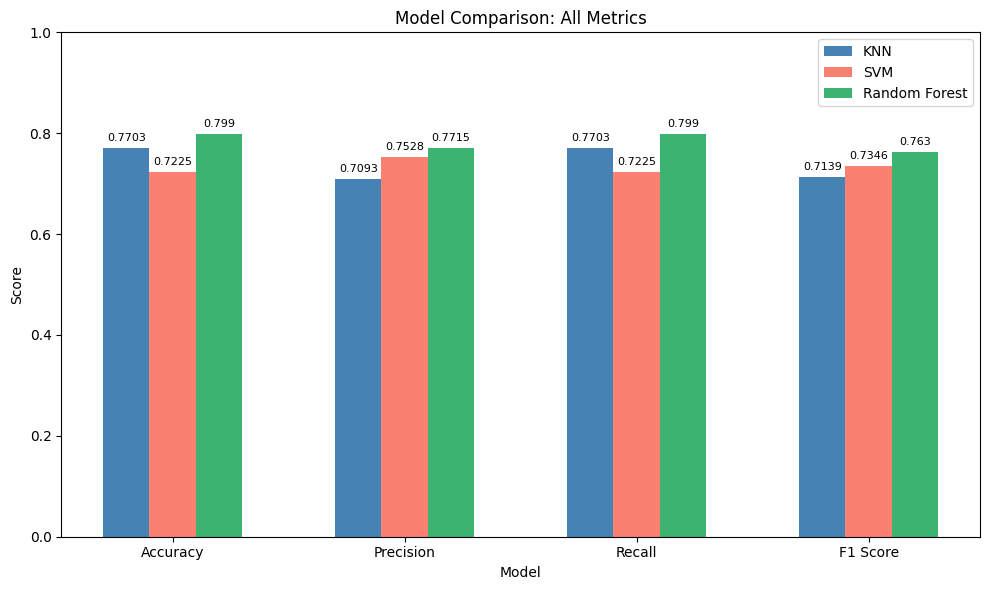

In [ ]:
x = np.arange(4)
width = 0.2

knn_scores = [
    round(accuracy_score(y_test, y_pred_knn), 4),
    round(precision_score(y_test, y_pred_knn, average='weighted'), 4),
    round(recall_score(y_test, y_pred_knn, average='weighted'), 4),
    round(f1_score(y_test, y_pred_knn, average='weighted'), 4)
]

svm_scores = [
    round(accuracy_score(y_test, y_pred_svm), 4),
    round(precision_score(y_test, y_pred_svm, average='weighted'), 4),
    round(recall_score(y_test, y_pred_svm, average='weighted'), 4),
    round(f1_score(y_test, y_pred_svm, average='weighted'), 4)
]

rf_scores = [
    round(accuracy_score(y_test, y_pred_rf), 4),
    round(precision_score(y_test, y_pred_rf, average='weighted'), 4),
    round(recall_score(y_test, y_pred_rf, average='weighted'), 4),
    round(f1_score(y_test, y_pred_rf, average='weighted'), 4)
]

metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

plt.figure(figsize=(10, 6))
plt.bar(x - width, knn_scores, width, label='KNN', color='steelblue')
plt.bar(x, svm_scores, width, label='SVM', color='salmon')
plt.bar(x + width, rf_scores, width, label='Random Forest', color='mediumseagreen')

for i, v in enumerate(knn_scores):
    plt.text(i - width, v + 0.01, str(v), ha='center', va='bottom', fontsize=8)

for i, v in enumerate(svm_scores):
    plt.text(i, v + 0.01, str(v), ha='center', va='bottom', fontsize=8)

for i, v in enumerate(rf_scores):
    plt.text(i + width, v + 0.01, str(v), ha='center', va='bottom', fontsize=8)

plt.title('Model Comparison: All Metrics')
plt.xlabel('Model')
plt.ylabel('Score')
plt.xticks(x, metric_labels)
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()